### NYC 311 Service Requests — Data Preprocessing

This notebook prepares raw NYC 311 service request data for machine learning modeling.

The objective of the project is to predict whether a complaint will be resolved within one week of submission. To support this goal, the preprocessing workflow performs the following steps:

1. Load and inspect the raw data
2. Remove features that may introduce data leakage
3. Create the modeling target variable
4. Engineer time-based features
5. Clean and standardize geographic information
6. Handle categorical variables and missing values
7. Remove non-predictive identifiers
8. Export the cleaned dataset for feature engineering and modeling

The output of this notebook is a cleaned dataset ready for exploratory analysis.

#### Import libaries
The required Python libraries for data manipulation and preprocessing are imported here.

Key libraries used:

- **pandas / numpy** – data manipulation and transformation
- **datetime** / **time** – handling temporal fields

These tools support efficient cleaning and transformation of NYC 311 service request data.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np
import requests
import time
import datetime
from pathlib import Path

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
from pathlib import Path

# Import requests for API pulls
import requests

# Improve plot styling
sns.set()

# Show all columns during EDA
pd.set_option('display.max_columns', None)

In [2]:
# File paths
PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DATA_DIR = PROJECT_ROOT / "data/clean_data"
RAW_DATA_DIR = PROJECT_ROOT / "data/raw_data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

#### Import data
The raw NYC 311 dataset is loaded into a pandas DataFrame.

The dataset contains service request records including:

- complaint metadata
- timestamps
- geographic identifiers
- agency information
- complaint classifications

Initial inspection is performed to confirm that the data loads correctly and to understand the structure of the dataset.

In [3]:
# Import data
data = pd.read_csv(RAW_DATA_DIR / "311_Service_Requests_from_2020_to_Present_20260416.csv", 
                   usecols=["Unique Key", "Created Date", "Closed Date", "Agency", "Agency Name", 
                            "Problem (formerly Complaint Type)", "Problem Detail (formerly Descriptor)", 
                            "Location Type", "Incident Zip", "Status", "BBL", "Borough", "Latitude", "Longitude"
                           ],
                   low_memory=False)

#### Details of data
Before preprocessing begins, I examined the structure of the dataset:

- number of observations
- feature data types
- missing values
- potential identifiers or non-predictive fields

Understanding the dataset structure helps guide me preprocessing decisions and identify columns that may require cleaning or transformation.

In [4]:
# Show first five records of data
data.head(5)

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Location Type,Incident Zip,Status,BBL,Borough,Latitude,Longitude
0,68525085,03/31/2026 11:59:54 PM,NaN,HPD,Department of Housing Preservation and Develop...,WATER LEAK,HEAVY FLOW,RESIDENTIAL BUILDING,11208,Open,3.041300e+09,BROOKLYN,40.683468,-73.872864
1,68517453,03/31/2026 11:59:51 PM,04/01/2026 01:52:27 AM,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11201,Closed,NaN,BROOKLYN,40.700270,-73.989768
2,68524357,03/31/2026 11:59:45 PM,04/01/2026 12:55:52 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10032,Closed,1.021260e+09,MANHATTAN,40.841393,-73.936836
3,68525398,03/31/2026 11:59:45 PM,04/01/2026 08:30:14 PM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,11207,Closed,3.044158e+09,BROOKLYN,40.655826,-73.883387
4,68523169,03/31/2026 11:59:26 PM,04/01/2026 12:33:29 AM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11212,Closed,3.035670e+09,BROOKLYN,40.662033,-73.916598


In [5]:
# Number of rows and columns
data.shape

(4076636, 14)

In [6]:
# Standardize column names
data.columns = (
    data.columns.str.strip()
             .str.lower()
             .str.replace(" ", "_")
             .str.replace("-", "_")
)

data.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'problem_(formerly_complaint_type)',
       'problem_detail_(formerly_descriptor)', 'location_type', 'incident_zip',
       'status', 'bbl', 'borough', 'latitude', 'longitude'],
      dtype='object')

In [7]:
data.rename(columns={
    "problem_(formerly_complaint_type)":"complaint_type",
    'problem_detail_(formerly_descriptor)':"descriptor"
}, inplace=True)

data.head(5)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,status,bbl,borough,latitude,longitude
0,68525085,03/31/2026 11:59:54 PM,NaN,HPD,Department of Housing Preservation and Develop...,WATER LEAK,HEAVY FLOW,RESIDENTIAL BUILDING,11208,Open,3.041300e+09,BROOKLYN,40.683468,-73.872864
1,68517453,03/31/2026 11:59:51 PM,04/01/2026 01:52:27 AM,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11201,Closed,NaN,BROOKLYN,40.700270,-73.989768
2,68524357,03/31/2026 11:59:45 PM,04/01/2026 12:55:52 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10032,Closed,1.021260e+09,MANHATTAN,40.841393,-73.936836
3,68525398,03/31/2026 11:59:45 PM,04/01/2026 08:30:14 PM,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,11207,Closed,3.044158e+09,BROOKLYN,40.655826,-73.883387
4,68523169,03/31/2026 11:59:26 PM,04/01/2026 12:33:29 AM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11212,Closed,3.035670e+09,BROOKLYN,40.662033,-73.916598


In [8]:
# Number of unique keys
data["unique_key"].drop_duplicates()
data.shape

(4076636, 14)

In [9]:
# Data types along with count of missing
types_null_counts = pd.DataFrame()
types_null_counts["Data Type"] = data.dtypes
types_null_counts["Count of Nulls"] = data.isna().sum()
types_null_counts

,Data Type,Count of Nulls
unique_key,int64,0
created_date,object,0
closed_date,object,143876
agency,object,0
agency_name,object,0
complaint_type,object,0
descriptor,object,84967
location_type,object,506112
incident_zip,object,35490
status,object,0


#### Drop 'status' to avoid leakage
The `status` column is removed prior to modeling.

This variable reflects the final outcome of the complaint resolution process, which occurs after the request has already been handled.

Including this feature would introduce data leakage, allowing the model to indirectly observe the outcome it is trying to predict.

To ensure a realistic predictive modeling scenario, this column is excluded.

In [10]:
data = data.drop(columns=["status"], errors="ignore")
data.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip', 'bbl',
       'borough', 'latitude', 'longitude'],
      dtype='object')

#### Create target based on resolution time
The modeling target is derived from the difference between:

- **created_date**
- **closed_date**

The resolution time is calculated in days, and a binary target variable is created:

- **1 → resolved within 7 days**
- **0 → resolved after 7 days**

This formulation converts the problem into a binary classification task, enabling the use of standard machine learning algorithms.

In [13]:
# Set "created_date" as datetime
data["created_date"] = pd.to_datetime(
    data["created_date"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

In [14]:
# Set "closed_date" as datetime
data["closed_date"] = pd.to_datetime(
    data["closed_date"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

In [15]:
# Confirm data type of new datetime columns
data[["created_date", "closed_date"]].dtypes

created_date    datetime64[ns]
closed_date     datetime64[ns]
dtype: object

In [16]:
# Function for datetime resolution
data["resolution_time_days"] = (data["closed_date"] - data["created_date"]).dt.total_seconds() / 86400

data["resolution_in_wk"] = (data["resolution_time_days"] > 7).astype(int)

data.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,bbl,borough,latitude,longitude,resolution_time_days,resolution_in_wk
0,68525085,2026-03-31 23:59:54,NaT,HPD,Department of Housing Preservation and Develop...,WATER LEAK,HEAVY FLOW,RESIDENTIAL BUILDING,11208,3.041300e+09,BROOKLYN,40.683468,-73.872864,NaN,0
1,68517453,2026-03-31 23:59:51,2026-04-01 01:52:27,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,Street/Sidewalk,11201,NaN,BROOKLYN,40.700270,-73.989768,0.078194,0
2,68524357,2026-03-31 23:59:45,2026-04-01 00:55:52,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10032,1.021260e+09,MANHATTAN,40.841393,-73.936836,0.038970,0
3,68525398,2026-03-31 23:59:45,2026-04-01 20:30:14,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,Residential Building/House,11207,3.044158e+09,BROOKLYN,40.655826,-73.883387,0.854502,0
4,68523169,2026-03-31 23:59:26,2026-04-01 00:33:29,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11212,3.035670e+09,BROOKLYN,40.662033,-73.916598,0.023646,0


In [17]:
# Number of records in each class
data["resolution_in_wk"].value_counts()

resolution_in_wk
0    3490544
1     586092
Name: count, dtype: int64

In [18]:
data["resolution_time_days"].isna().sum()

143876

#### Time features
Temporal features are extracted from the complaint creation timestamp.

These features may capture patterns in service response times:

- hour of day
- day of week
- month

Time-based patterns can influence service resolution due to factors such as staffing levels, operational schedules, and complaint volume fluctuations.

In [19]:
# Hour, day of week, month of complaint
data = data.dropna(subset=["resolution_time_days"]).copy()

data["complaint_hr"] = data["created_date"].dt.hour
data["complaint_day"] = data["created_date"].dt.dayofweek
data["complaint_month"] = data["created_date"].dt.month

#### Borough & ZIP Code
Geographic identifiers are cleaned and standardized to ensure consistency.

Borough and ZIP code information can influence complaint resolution time due to:

- service workload differences
- agency resource distribution
- neighborhood characteristics

Ensuring valid NYC geographic identifiers improves model reliability.

In [20]:
# Change all ZIP Codes to strings
data["incident_zip"] = data["incident_zip"].astype(str).str.strip()
data["incident_zip"] = data["incident_zip"].str[:5]

In [21]:
# Further standardize ZIP Code format
data["incident_zip"] = data["incident_zip"].replace("nan", np.nan)
data["incident_zip"] = data["incident_zip"].where(
    data["incident_zip"].str.fullmatch(r"\d{5}", na=False),
    np.nan
)

In [22]:
# Official NYC ZIP Code source
nyc_zips = pd.read_csv(RAW_DATA_DIR / "sf1p11.csv")
nyc_zips.head()

,Borough,ZIPCODES
0,Manhattan,10001
1,Manhattan,10002
2,Manhattan,10003
3,Manhattan,10004
4,Manhattan,10005


In [23]:
# Reference df cleaned
zip_ref = nyc_zips[["ZIPCODES", "Borough"]].copy()
zip_ref.columns = ["incident_zip", "borough_official"]

zip_ref["incident_zip"] = zip_ref["incident_zip"].astype(str).str.strip().str[:5]

zip_ref["borough_official"] = (
    zip_ref["borough_official"]
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [24]:
# Standardize borough in 311 data before comparison
data["borough"] = (
    data["borough"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .replace("unspecified", np.nan)
    .replace("nan", np.nan)
)

In [25]:
# Keep only NYC ZIP Codes
data = data[data["incident_zip"].isin(zip_ref["incident_zip"])].copy()

In [26]:
# Merge official borough
data = data.merge(
    zip_ref,
    on="incident_zip",
    how="left"
)

In [27]:
# Compare boroughs
borough_mismatch = data[
    data["borough"].notna() &
    (data["borough"] != data["borough_official"])
]
borough_mismatch.shape

(49786, 19)

In [28]:
# Set borough based in '311' set based on NYC official borough
data["borough"] = data["borough_official"]
data = data.drop(columns=["borough_official"])

In [29]:
# Count of boroughs
data["borough"].value_counts(dropna=False)

borough
brooklyn         1163118
queens            951685
bronx             863573
manhattan         777732
staten_island     159643
Name: count, dtype: int64

In [30]:
# Reset index as values have been removed
data = data.reset_index(drop=True)

#### Latitude & Longitude
Latitude and longitude values are retained as location features.

These coordinates allow spatial patterns in service response to be captured by the model and may be used later for:

- spatial feature engineering
- proximity calculations
- geographic visualization in dashboards

In [31]:
# Convert coordinates to numeric
data["latitude"] = pd.to_numeric(data["latitude"], errors="coerce")
data["longitude"] = pd.to_numeric(data["longitude"], errors="coerce")

In [32]:
# Describe latitude
data["latitude"].describe()

count    3.871247e+06
mean     4.073895e+01
std      8.868552e-02
min      4.049891e+01
25%      4.067330e+01
50%      4.073147e+01
75%      4.082191e+01
max      4.091287e+01
Name: latitude, dtype: float64

In [33]:
# Missing values
data["latitude"].isna().sum()

44504

In [34]:
# Describe longitude
data["longitude"].describe()

count    3.871247e+06
mean    -7.392070e+01
std      7.695000e-02
min     -7.425495e+01
25%     -7.396312e+01
50%     -7.392208e+01
75%     -7.387279e+01
max     -7.370037e+01
Name: longitude, dtype: float64

In [35]:
# Missing values
data["longitude"].isna().sum()

44504

In [36]:
# Check if the same rows are missing both
missing_long_lat = data[(data["latitude"].isna()) & (data["longitude"].isna())]
missing_long_lat.shape

(44504, 18)

In [37]:
# Drop columns where longitude and latitude are missing
data = data.dropna(subset=["longitude", "latitude"]).copy()

In [38]:
# Check counts after dropping
data.shape

(3871247, 18)

#### Complaint Type
Complaint type is one of the most important predictors in the dataset.

Different complaint categories (e.g., noise complaints, sanitation issues, street conditions) may have  different resolution timelines depending on the responsible agency and operational complexity.

This feature is preserved as a categorical predictor for the model.

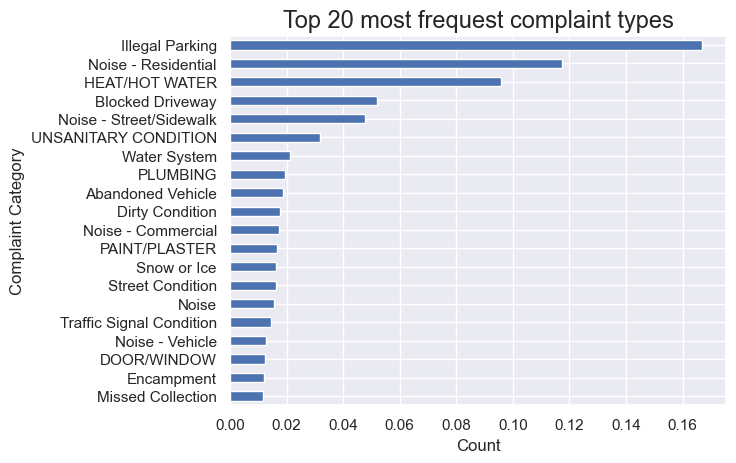

In [39]:
# Top 20 most types of complaints
data["complaint_type"].value_counts(normalize=True).head(20).sort_values().plot.barh()
plt.xlabel("Count")
plt.ylabel("Complaint Category")
plt.title("Top 20 most frequest complaint types", fontsize=17)
plt.show()

In [40]:
# Number of unique complaint types
data["complaint_type"].nunique()

176

In [41]:
# Check for missingness
data["complaint_type"].isna().sum()

0

#### Descriptor
The descriptor field provides more detailed classification within each complaint type.

For example, a noise complaint may have descriptors indicating:

- loud music
- blocked hydrant
- no access

These finer-grained distinctions may help the model capture variation in expected resolution times.

In [42]:
# Number of unique descriptions
data["descriptor"].nunique()

891

In [43]:
data["descriptor"].isna().sum()

71742

In [44]:
# Top 15 descriptors
data["descriptor"].value_counts().head(15)

descriptor
Loud Music/Party                 474535
ENTIRE BUILDING                  241019
Blocked Hydrant                  186946
Banging/Pounding                 151161
Posted Parking Sign Violation    149585
No Access                        149477
APARTMENT ONLY                   129792
Blocked Sidewalk                  92308
Loud Talking                      85027
Trash                             73835
With License Plate                72530
PESTS                             63905
Partial Access                    51655
Commercial Overnight Parking      45913
Derelict Vehicles                 41115
Name: count, dtype: int64

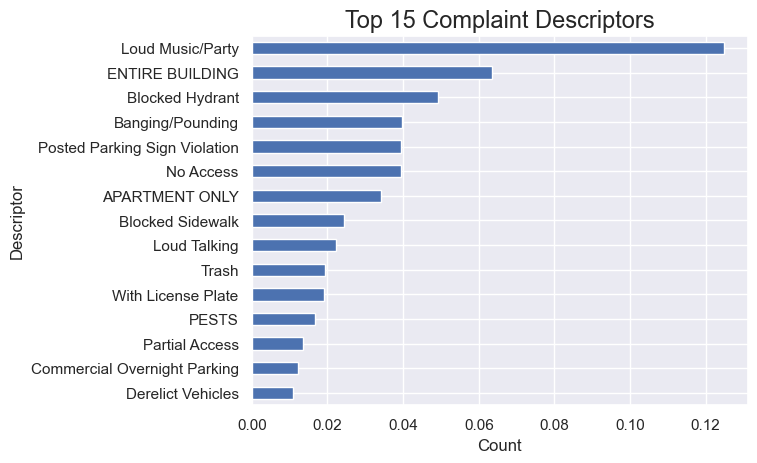

In [45]:
data["descriptor"].value_counts(normalize=True).head(15).sort_values().plot.barh()
plt.xlabel("Count")
plt.ylabel("Descriptor")
plt.title("Top 15 Complaint Descriptors", fontsize=17)
plt.show()

#### Agency
Each complaint is routed to a responsible city agency.

Different agencies operate under different workloads, response protocols, and staffing levels, which may influence resolution time.

This feature is therefore retained as a categorical predictor.

In [46]:
# Count of each agency with which the complaint was routed
data["agency"].value_counts(dropna=False)

agency
NYPD          1827812
HPD            858396
DSNY           378744
DEP            210336
DOT            208296
DOB            115666
DPR             94820
DOHMH           82088
DHS             44427
TLC             23069
DCWP            19376
EDC              4270
DOE              1841
OOS              1725
OTI               201
NYC311-PRD        180
Name: count, dtype: int64

In [47]:
# Number of unique departments listed
data["agency"].nunique()

16

#### Location Type
The location type describes the setting of the complaint, such as:

- residential building
- street or sidewalk
- commercial property

These contextual details may influence the complexity of resolving a request and are therefore preserved as a modeling feature.

In [48]:
data["location_type"].value_counts(dropna=False)

location_type
Street/Sidewalk               1255479
RESIDENTIAL BUILDING           858396
Residential Building/House     496761
NaN                            446479
Street                         325522
                               ...   
Swamp or Pond                       2
Tire Shop                           2
Sports Arena                        2
Horse Stable                        1
Subway                              1
Name: count, Length: 143, dtype: int64

In [49]:
data["location_type"].nunique()

142

#### Handle categorical columns' missingness
Missing values in categorical variables are addressed prior to modeling.

Rather than dropping observations, missing values are filled with an **"Unknown" or equivalent category**, allowing the model to retain all available data while still capturing potential patterns associated with missing information.

In [50]:
categorical_cols = [
    "complaint_type",
    "descriptor",
    "location_type",
    "borough",
    "incident_zip"
]

for col in categorical_cols:
    data[col] = data[col].fillna("unknown")

#### Drop columns not needed for modeling
Certain columns are removed because they do not provide predictive value or serve only as identifiers.

Removing these features ensures the model is trained only on information that would be available when making real-time predictions.

In [51]:
data = data.drop(columns=["closed_date", "agency_name", "created_date", "bbl"], errors="ignore")

#### Export preprocessed data
The final cleaned dataset is exported for use in downstream notebooks.

This dataset serves as the input for:

- feature engineering
- model training
- model evaluation

Separating preprocessing and modeling steps helps maintain a clear and reproducible machine learning workflow.

In [52]:
# Final check of data
data.isna().sum().sort_values(ascending=False)
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
Index: 3871247 entries, 0 to 3915750
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   unique_key            int64  
 1   agency                object 
 2   complaint_type        object 
 3   descriptor            object 
 4   location_type         object 
 5   incident_zip          object 
 6   borough               object 
 7   latitude              float64
 8   longitude             float64
 9   resolution_time_days  float64
 10  resolution_in_wk      int32  
 11  complaint_hr          int32  
 12  complaint_day         int32  
 13  complaint_month       int32  
dtypes: float64(3), int32(4), int64(1), object(6)
memory usage: 384.0+ MB


(3871247, 14)

In [53]:
# Export to parquet file
data.to_parquet(CLEAN_DATA_DIR / "01_nyc_info_preprocessing.parquet", index=False)